# Analisis Exploratorio de Datos del dataset PlantVillage
Nombres: 
- Alejandro Reyes V.
- Felipe Sánchez C.
___

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

## Estructura del Dataset:

Se trabajará con el dataset PlantVillage de 'spMoganty', el cual se puede obtener desde el [repositorio oficial en github](https://github.com/spMohanty/PlantVillage-Dataset.git) o desde [su pagina en Kaggle](https://www.kaggle.com/datasets/mohitsingh1804/plantvillage)

Este dataset contiene 38 tipos de plantas, con un total de 54305 imágenes que incluyen plantas sanas y con pestes. En total, el dataset cubre 14 especies de cultivos, entre los cuales se encuentran manzanos, naranjos, cerezos, entre otros.

Para efectos de este proyecto, los cultivos relevantes son Cerezos, que en el dataset se separan en 2 carpetas (sanos y con peste), y que a su vez se distribuyen en conjuntos de entrenamiento y validación (train/ y val/).

In [44]:

!ls cherry_disease/train/
!ls cherry_disease/val/



"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [45]:
import os

# Dimensiones del dataset

blanquilla_num_train = len(os.listdir('./dataset/train/Cherry_(including_sour)___Powdery_mildew'))
sana_num_train = len(os.listdir('./dataset/train/Cherry_(including_sour)___healthy'))
total = blanquilla_num_train + sana_num_train

blanquilla_num_val = len(os.listdir('./dataset/val/Cherry_(including_sour)___Powdery_mildew'))
sana_num_val = len(os.listdir('./dataset/val/Cherry_(including_sour)___healthy'))
total_val = blanquilla_num_val + sana_num_val

print("Número total de imágenes en el dataset(train):", total)
print("Número de imágenes de hojas con blanquilla:", blanquilla_num_train, "({:.2f}%)".format((blanquilla_num_train / total) * 100))
print("Número de imágenes de hojas sanas:", sana_num_train, "({:.2f}%)".format((sana_num_train / total) * 100))
print("----------------------------------------------------------------")
print("Número total de imágenes en el dataset(validation):", total_val)
print("Número de imágenes de hojas con blanquilla:", blanquilla_num_val, "({:.2f}%)".format((blanquilla_num_val / total_val) * 100))
print("Número de imágenes de hojas sanas:", sana_num_val, "({:.2f}%)".format((sana_num_val / total_val) * 100))

Número total de imágenes en el dataset(train): 1526
Número de imágenes de hojas con blanquilla: 842 (55.18%)
Número de imágenes de hojas sanas: 684 (44.82%)
----------------------------------------------------------------
Número total de imágenes en el dataset(validation): 380
Número de imágenes de hojas con blanquilla: 210 (55.26%)
Número de imágenes de hojas sanas: 170 (44.74%)


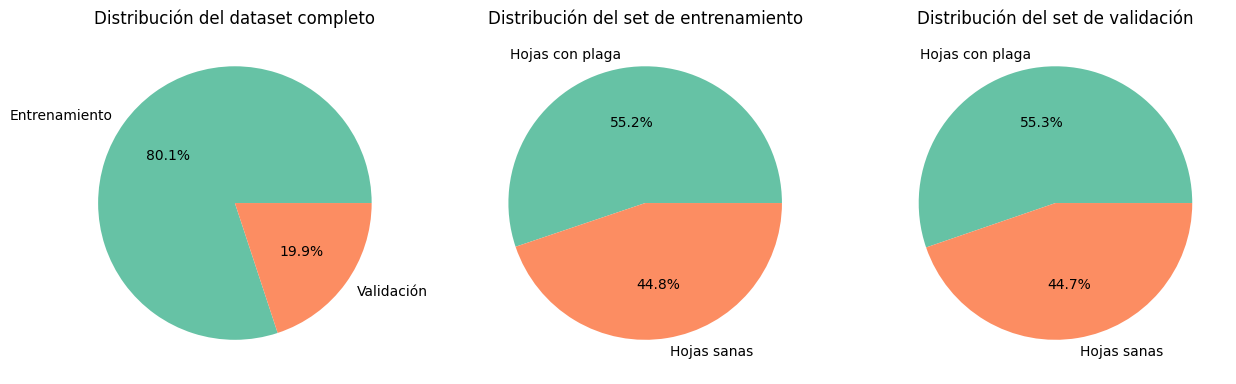

In [46]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.pie([total, total_val], labels=['Entrenamiento', 'Validación'], autopct='%1.1f%%', colors= plt.cm.Set2.colors)
ax1.set_title('Distribución del dataset completo')

ax2.pie([blanquilla_num_train, sana_num_train], labels=['Hojas con plaga', 'Hojas sanas'], autopct='%1.1f%%', colors= plt.cm.Set2.colors)
ax2.set_title('Distribución del set de entrenamiento')

ax3.pie([blanquilla_num_val, sana_num_val], labels=['Hojas con plaga', 'Hojas sanas'], autopct='%1.1f%%', colors= plt.cm.Set2.colors)
ax3.set_title('Distribución del set de validación')

plt.show()

### Distribución del dataset

Desde lo anterior se obtiene que la totalidad del conjunto de entrenamiento es de 1526 imágenes. De las cuales el 55.2% corresponde a hojas con blanquilla, y el 44.8% a hojas sanas.
Esto demuestra que las clases (sana / enferma) estan balanceadas.

Por otro lado, el conjunto de validacion incluye un total de 380 imágenes, 55.3% de hojas con peste y 44.7% de hojas sanas.

Lo anterior indica que el dataset sigue una proporcion de 80/20 en training y validation.


Para efectos de este proyecto, y para evitar resultados pre-fabricados, se realizará un shuffle entre el conjunto de entrenamiento y de validación, manteniendo las proporciones.

In [47]:
# shuffle entre train y val, manteniendo la proporción de clases

train_directory = './dataset/train'
val_directory = './dataset/val'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    labels='inferred',       # infiere la etiqueta desde el nombre de la carpeta
    label_mode='binary',     # usar binary pues se tiene hojas sanas y enfermas
)

nombres_clases = train_dataset.class_names
print(f"Clases detectadas:", {nombre for nombre in nombres_clases})

Found 1526 files belonging to 2 classes.
Clases detectadas: {'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy'}


In [67]:
# Exploramos el dataset para ver la regularidad de las imágenes
from PIL import Image
from pathlib import Path

paths = [
    Path("./dataset/train/Cherry_(including_sour)___healthy"),
    Path("./dataset/train/Cherry_(including_sour)___Powdery_mildew"),
    Path("./dataset/val/Cherry_(including_sour)___healthy"),
    Path("./dataset/val/Cherry_(including_sour)___Powdery_mildew"),
]

def obtener_medidas(path):
    ancho_min = float("inf") # Usamos un valor exageradamente grande para asegurar que no habrá uno mas pequeño
    alto_min = float("inf")
    ancho_max = 0
    alto_max = 0
    for imagen in path.iterdir():
        with Image.open(imagen) as img:
            ancho, alto = img.size

            ancho_min = min(ancho_min, ancho)
            alto_min = min(alto_min, alto)
            ancho_max = max(ancho_max, ancho)
            alto_max = max(alto_max, alto)

    print(f"Ancho mínimo: {ancho_min}")
    print(f"Ancho máximo: {ancho_max}")
    print(f"Alto mínimo: {alto_min}")
    print(f"Alto máximo: {alto_max}")

for path in paths:
    obtener_medidas(path)


Ancho mínimo: 256
Ancho máximo: 256
Alto mínimo: 256
Alto máximo: 256
Ancho mínimo: 256
Ancho máximo: 256
Alto mínimo: 256
Alto máximo: 256
Ancho mínimo: 256
Ancho máximo: 256
Alto mínimo: 256
Alto máximo: 256
Ancho mínimo: 256
Ancho máximo: 256
Alto mínimo: 256
Alto máximo: 256


Se observa que todas las imágenes tienen las mismas dimensiones, por lo que ya se encuentran regularizadas en este ámbito en específico.

### Vista previa del Dataset

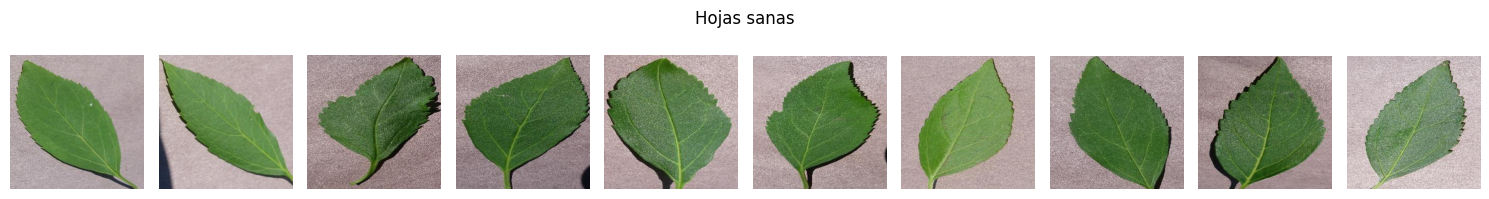

In [80]:
ruta_images_sanas = os.listdir(paths[0])
images = [img for img in ruta_images_sanas]

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle("Hojas sanas", fontsize=12)

for ax in axes:
    nombre_img = random.choice(images)
    ruta_img = paths[0] / nombre_img
    img = Image.open(ruta_img)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

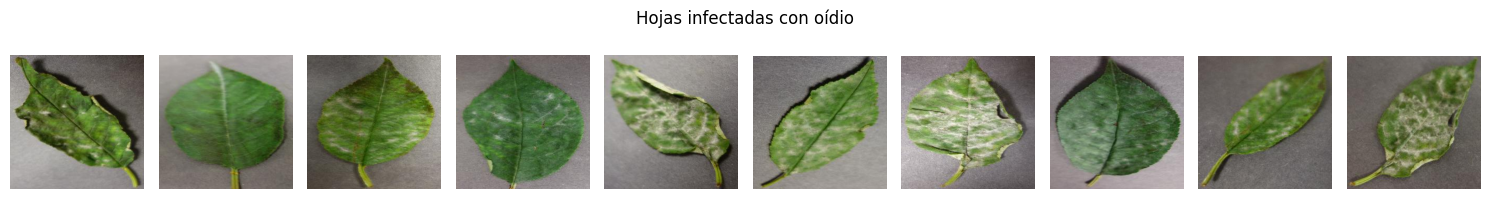

In [85]:
ruta_images_plaga = os.listdir(paths[1])
images_plaga = [img for img in ruta_images_plaga]

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle("Hojas infectadas con oídio", fontsize=12)

for ax in axes:
    nombre_img = random.choice(images_plaga)
    ruta_img = paths[1] / nombre_img
    img = Image.open(ruta_img)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

Se puede observar que las imágenes presentan fondos y ángulos de iluminación muy similares, asegurando que las muestras que se toman sean de calidad y puedan ayudar a entrenar de mejor manera el modelo.